In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from scipy.integrate import simpson as simps
import os

from scipy.integrate import trapezoid

from scipy.interpolate import Akima1DInterpolator

from scipy.interpolate import PchipInterpolator

In [6]:
xs_data = pd.read_excel(r'F:\P-529990 Joydeppur Iswardi Double Rail Line\Model For B#23 Boral River\Boundary\XS_Data_ID81.xlsx')
xs_data.head(10)

,Distance,RL_mMSL
0,0,11.817
1,5,11.664
2,6,11.194
3,9,10.039
4,11,9.297
5,12,8.876
6,14,8.022
7,15,7.481
8,16,6.797
9,18,6.160


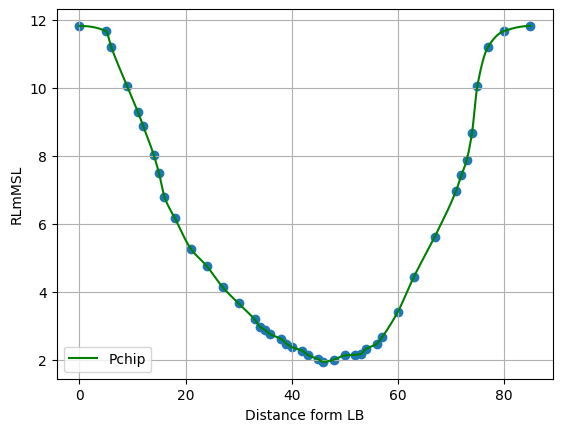

In [7]:
x = xs_data['Distance']
y = xs_data['RL_mMSL']

# Interpolate finer resolution
x_dense = np.linspace(x.min(), x.max(), 1000)
# f_qurd = interp1d(x, y, kind='quadratic')   # Not Suitable for river
# y_qurd = f_qurd(x_dense)

f_php = PchipInterpolator(x, y)               # Best for XS Interpolation
y_php = f_php(x_dense)

# f_akima = Akima1DInterpolator(x, y)           # Better for XS Interpolation
# y_akima = f_akima(x_dense)

plt.scatter(xs_data['Distance'],xs_data['RL_mMSL'])
# plt.plot(x_dense,y_qurd,color = 'red',linestyle = '-', label='Qurdatric')
plt.plot(x_dense,y_php,color = 'green',linestyle = '-', label='Pchip')
#plt.plot(x_dense,y_akima,color = 'blue',linestyle = '-', label='Akima')
plt.legend()
plt.grid()
plt.xlabel('Distance form LB')
plt.ylabel('RLmMSL')
plt.show()

In [8]:
file_path = r'F:\P-529990 Joydeppur Iswardi Double Rail Line\Model For B#23 Boral River\Boundary\WL_Data_All_Flood_Event_Year.xlsx'
xls = pd.ExcelFile(file_path)
print(xls.sheet_names)

['1988 100yr', '2017 50yr', '2004 25yr', '2008 2.33yr', 'Calibration 2020']


In [32]:
WL_data = pd.read_excel(file_path, sheet_name='1988 100yr')
WL_data['Date'] = pd.to_datetime(WL_data['Date'])
WL_data.head(10)

,Date,WL_mMSL_Original,WL_mMSL
0,1988-01-01 12:00:00,4.48,4.53
1,1988-01-02 12:00:00,4.54,4.59
2,1988-01-03 12:00:00,4.53,4.58
3,1988-01-04 12:00:00,4.52,4.57
4,1988-01-05 12:00:00,4.51,4.56
5,1988-01-06 12:00:00,4.51,4.56
6,1988-01-07 12:00:00,4.48,4.53
7,1988-01-08 12:00:00,4.47,4.52
8,1988-01-09 12:00:00,4.47,4.52
9,1988-01-10 12:00:00,4.47,4.52


0.9479918955972224
512.5795386779906


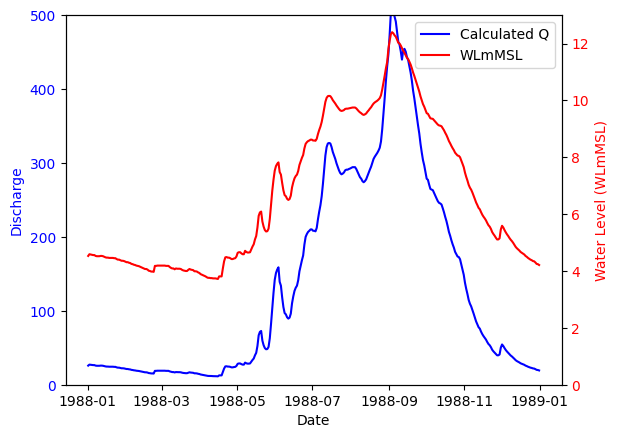

In [ ]:
WL = WL_data
y_dense = y_php
x_dense = np.linspace(x.min(), x.max(), 1000)
n_manning = 0.025
S = 0.000050
results = []

for _, row in WL.iterrows():
    date = row['Date']
    water_level = row['WL_mMSL']

    submerged = y_dense < water_level
    x_sub = x_dense[submerged]
    y_sub = y_dense[submerged]

    if len(x_sub) < 2:
        area = 0
        wetted_perimeter = 0
        hydraulic_radius = 0
        velocity = 0
        discharge = 0
    else:
        water_depth = water_level - y_sub
        area = trapezoid(water_depth, x_sub)
        dx = np.diff(x_sub)
        dy = np.diff(y_sub)
        segment_lengths = np.sqrt(dx**2 + dy**2)
        wetted_perimeter = np.sum(segment_lengths)
        hydraulic_radius = area / wetted_perimeter if wetted_perimeter > 0 else 0
        
        velocity = (1 / n_manning) * (hydraulic_radius**(2/3)) * (S**0.5) if hydraulic_radius > 0 else 0
        discharge = velocity * area

    results.append({
        'Date': date,
        'WLmMSL': water_level,
        'Area': area,
        'Wetted_Perimeter': wetted_perimeter,
        'Hydraulic_Radius': hydraulic_radius,
        'n_manning': n_manning,
        'Velocity': velocity,
        'Discharge': discharge
    })

Calculated_Discharge = pd.DataFrame(results)
Calculated_Discharge['Date'] = pd.to_datetime(Calculated_Discharge['Date'])
print(Calculated_Discharge['Velocity'].max())
print(Calculated_Discharge['Discharge'].max())

Calculated_Discharge.head()

fig, ax1 = plt.subplots()

# First axis (Discharge)
ax1.plot(
    Calculated_Discharge['Date'],
    Calculated_Discharge['Discharge'],
    label='Calculated Q',
    color='blue'
)
ax1.set_xlabel('Date')
ax1.set_ylabel('Discharge', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_ylim(0,500)


# Second axis (Water Level)
ax2 = ax1.twinx()
ax2.plot(
    Calculated_Discharge['Date'],
    Calculated_Discharge['WLmMSL'],
    label='WLmMSL',
    color='red'
)
ax2.set_ylabel('Water Level (WLmMSL)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0,13)


# Optional: combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.show()

# Calculated_Discharge.to_csv(r'F:\P-529990 Joydeppur Iswardi Double Rail Line\Model For B#23 Boral River\Boundary\Baral_Boundary_1988 100yr.csv', index=False)